# Practical Sleep Analysis

## Sleep Analysis Code for up to 3 groups

This code is designed to be run in one fell swoop with all the preparation needed being done in the first few lines. If the amount of groups is different than here, you may need to change stuff - otherwise it should work.

## 1) Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statistics as stats
import scipy.stats as ss #requires at least version 1.16.0
import os
import datetime
from tkinter import filedialog

## User Instructions
Please input filepaths to the FOLDER containing your data for a specific condition in the cell below. The folder should in turn contain the **folders** with your pre-analized (Matlab) Sleep Analysis data.

Example:

"Controls" 
    <br>> "2025_10_13_Control_Box1"</br>
       > "2025_10_14_Control_Box1"
    <br>> "2025_10_15_Control_Box1"</br>
   ... etc.

Ideally, this is the only cell you need to interact with. 

All results will be saved to the path you specify as "path_graphics", including the results of the t-tests in a .txt file. Aside from adding groups (or unprecedented errors) there are no real reasons for you to interact with other cells.

### Check binning parameters, groups and folder paths here!

In [73]:
#Which time did you use for binning? (In Matlab)
binned = 1 #in minutes
'''Which limit to set for the y-axis on the graphics?'''
lim_y = 30 #for sleep
lim_y_wake = 15
'''Limits to set for bar plots'''
lim_y_bp_sleep = 60
lim_y_bp_wake = 15

#How many groups are there (including the control)? (Currently supports 2 or 3)
group_nr = 3
#Which names do you want to give your groups? (strings)
ctrl_name = "control"
group_1_name = "continuous light"
group_2_name = "light pulses"

'''Statistische Tests alle Kruskal-Wallis Tests?'''
#Only relevant if you have >2 group_nr
## Change to True if later tests were Kruskal-Wallis and automatic recognition for first tests gave ANOVA
## Or if you just want all of them to be Kruskal-Wallis tests without testing for ANOVA possibility
kruskal_var = True #boolean, default: False

#filepaths for the folder containing your group data
ctrl_filepath = r"G:\Lehre\SystemsNeuroscience_Bachelor\Example_data\Sleep_Deprivation\2025_06_27_SD_Chiara\2025_06_27_Control_Box1"
grp1_filepath = r"G:\Lehre\SystemsNeuroscience_Bachelor\Example_data\Sleep_Deprivation\2025_06_27_SD_Chiara\2025_06_27_ContinuousLight_Box4"
grp2_filepath = r"G:\Lehre\SystemsNeuroscience_Bachelor\Example_data\Sleep_Deprivation\2025_06_27_SD_Chiara\2025_06_27_LP_Box2"


#This is where you'll save your graphics in the last step
# Create this folder on your harddrive
path_graphics = r"G:\Lehre\SystemsNeuroscience_Bachelor\Example_data\Sleep_Deprivation\2025_06_27_SD_Chiara\Results"

#ctrl_filepath = filedialog.askdirectory()
#grp1_filepath = filedialog.askdirectory()
#grp2_filepath = filedialog.askdirectory()
#path_graphics = filedialog.askdirectory()

In [13]:
# set up output file for t-test data
name_of_file = "statistics_output"
output_file = os.path.join(path_graphics, name_of_file+".txt") 

x = datetime.datetime.now()

with open(output_file, "w") as f:
    f.write("Output from: "+x.strftime("%d"+" "+"%b"+" "+"%Y")+"\n") #adds date to output file

In [23]:
#Define the statistics function
def statistics(kruskal_var, output_file, list_dfs, list_names):
    #Levene's Test (tests for equal variances)
    with open(output_file, "a") as f:
        f.write("\n"+"Levene's Test (for equal variances) using median (see Brown-Forsythe)"+"\n")
    if len(list_dfs) == 2:
        df1 = list_dfs[0]
        df2 = list_dfs[1]
        name1 = str(list_names[0])
        name2 = str(list_names[1])
        levene_stat, levene_p=ss.levene(df1, df2)
        with open(output_file, "a") as f:
            f.write("Included groups: "+str(name1)+" & "+str(name2)+"\n")
            f.write("Stat: "+str(levene_stat)+" p-value: "+str(levene_p)+"\n")
    elif len(list_dfs) == 3:
        df1 = list_dfs[0]
        df2 = list_dfs[1]
        df3 = list_dfs[2]
        name1 = str(list_names[0])
        name2 = str(list_names[1])
        name3 = str(list_names[2])
        levene_stat, levene_p=ss.levene(df1, df2, df3)
        with open(output_file, "a") as f:
            f.write("Included groups: "+str(name1)+" & "+str(name2)+" & "+str(name3)+"\n")
            f.write("Stat: "+str(levene_stat)+" p-value: "+str(levene_p)+"\n")   
    
    if levene_p > 0.05:
        var_equality=True
    else:
        var_equality=False
        
    #independent t-test for 2 groups
    if group_nr ==2:
        p = ss.ttest_ind(df1, df2, equal_var=var_equality)
        print(str(name1)+" vs "+str(name2)+" p: ", p)
        if levene_p > 0.5:
            test = "standard independent t-test"
        else:
            test = "Welch's independent t-test"
        with open(output_file, "a") as f:
            f.write("\n"+test+"\n")
            f.write(str(name1)+" vs "+str(name2)+"\n"+ str(p)+"\n")
    
    if len(list_dfs) >=3:
        '''Are the conditions for an ANOVA met?'''
        #Test for normality using a Shapiro-Wilk test for n<5000 and the scipy normaltest for larger n
        if len(df1)<5000 and len(df2)<5000 and len(df3)<5000:
            with open(output_file, "a") as f:
                f.write("\nTest for normal distribution (Shapiro-Wilk test):\n")
            stat_normal_control, p_normal_control = ss.shapiro(df1)
            stat_normal_grp1, p_normal_grp1 = ss.shapiro(df2)
            stat_normal_grp2, p_normal_grp2 = ss.shapiro(df3)
        else:
            with open(output_file, "a") as f:
                f.write("\nTest for normal distribution (scipy normaltest D'Agostino and Pearson's):\n")
            stat_normal_control, p_normal_control = ss.normaltest(df1)
            stat_normal_grp1, p_normal_grp1 = ss.normaltest(df2)
            stat_normal_grp2, p_normal_grp2 = ss.normaltest(df3)
        with open(output_file, "a") as f:
            f.write(str(name1)+": \n")
            f.write("Stat: "+str(stat_normal_control)+" p-value: "+str(p_normal_control)+"\n")
            f.write(str(name2)+": \n")
            f.write("Stat: "+str(stat_normal_grp1)+" p-value: "+str(p_normal_grp1)+"\n")
            f.write(str(name3)+": \n")
            f.write("Stat: "+str(stat_normal_grp2)+" p-value: "+str(p_normal_grp2)+"\n")
    
        if kruskal_var==True or p_normal_control <= 0.05 or p_normal_grp1 <= 0.05 or p_normal_grp2 <= 0.05:       
            #Carry out a Kruskal-Wallis H-test with Dunn post-hoc test if ANOVA is not possible
            stats_kruskal, p_kruskal = ss.kruskal(df1, df2, df3)
            kruskal_var=True
            print("Kruskal-Wallis H-test: "+"Stats: "+str(stats_kruskal)+" p-value: "+str(p_kruskal))
            with open(output_file, "a") as f:
                f.write("\nKruskal-Wallis H-test: \n"+"Stats: "+str(stats_kruskal)+" p-value: "+str(p_kruskal)+"\n")
            if p_kruskal > 0.05:
                print("Your groups do not differ significantly from each other. A post-hoc test is not needed.")
            else:
                #create pandas dataframe with one ID column and one data column for Dunn post-hoc test
                df_id_ctrl = pd.DataFrame({'ID':name1, 'data':df1.values})
                df_id_grp1 = pd.DataFrame({'ID':name2, 'data':df2.values})
                df_id_grp2 = pd.DataFrame({'ID':name3, 'data':df3.values})
                df_id = pd.concat([df_id_ctrl, df_id_grp1, df_id_grp2])
                
                result_dunn = str(sp.posthoc_dunn(df_id, val_col="data", group_col="ID"))
                print(result_dunn)
                with open(output_file, "a") as f:
                    f.write("\nDunn post-hoc test: \n"+result_dunn+"\n")
                
        else:
        #Levene's test already tested for homoscedasticity, which is why we can use the result here
            result_anova = ss.f_oneway(df1, df2, df3, equal_var=var_equality)
            result_tukey = ss.tukey_hsd(df1, df2, df3, equal_var=var_equality)
            if var_equality == True and len(df1)==len(df2) and len(df1)==len(df3):
                print("Standard ANOVA: "+str(result_anova))
                print("Tukey HSD test: "+str(result_tukey))
                with open(output_file, "a") as f:
                    f.write("\nStandard ANOVA: \n"+str(result_anova)+"\n")
                    f.write("Tukey HSD test: \n"+str(result_tukey)+"\n")
                
            elif var_equality == True:
                print("Standard ANOVA: "+str(result_anova))
                print("Tukey-Kramer test: "+str(result_tukey))
                with open(output_file, "a") as f:
                    f.write("\n Standard ANOVA: \n"+str(result_anova)+"\n")
                    f.write("Tukey-Kramer test: \n"+str(result_tukey)+"\n")
            else:
                print("Welch's ANOVA: "+str(result_anova))
                print("Games-Howell test: "+str(result_tukey))
                with open(output_file, "a") as f:
                    f.write("\n Welch's ANOVA: \n"+str(result_anova)+"\n")
                    f.write("Games-Howell test: \n"+str(result_tukey)+"\n")
    return kruskal_var

The next cell features the automatic setup of the follow up files as lists in order to concatenate them in the following step.

In [31]:
# --- Build dicts (only the specific CSV files) ---

#ctrl
ctrl_dict = {
    "act":      os.path.join(ctrl_filepath, "output_binned_act_ctrl.csv"),
    "rest":     os.path.join(ctrl_filepath, "output_binned_rest_ctrl.csv"),
    "wakeAct":  os.path.join(ctrl_filepath, "output_binned_wakeAct_ctrl.csv"),
}

#group1
cont_dict = {
    "act":      os.path.join(grp1_filepath, "output_binned_act_ctrl.csv"),
    "rest":     os.path.join(grp1_filepath, "output_binned_rest_ctrl.csv"),
    "wakeAct":  os.path.join(grp1_filepath, "output_binned_wakeAct_ctrl.csv"),
}

#group2
if group_nr >= 3:
    grp2_dict = {
        "act":      os.path.join(grp2_filepath, "output_binned_act_ctrl.csv"),
        "rest":     os.path.join(grp2_filepath, "output_binned_rest_ctrl.csv"),
        "wakeAct":  os.path.join(grp2_filepath, "output_binned_wakeAct_ctrl.csv"),
    }

# --- Read CSVs ---

#ctrl
df_Act_control    = pd.read_csv(ctrl_dict["act"],     header=None)
df_rest_control   = pd.read_csv(ctrl_dict["rest"],    header=None)
df_wakeAct_control= pd.read_csv(ctrl_dict["wakeAct"], header=None)

#group1
df_Act_continuouslight    = pd.read_csv(cont_dict["act"],     header=None)
df_rest_continuouslight   = pd.read_csv(cont_dict["rest"],    header=None)
df_wakeAct_continuouslight= pd.read_csv(cont_dict["wakeAct"], header=None)

#group2
if group_nr >= 3:
    df_Act_lp    = pd.read_csv(grp2_dict["act"],     header=None)
    df_rest_lp  = pd.read_csv(grp2_dict["rest"],    header=None)
    df_wakeAct_lp = pd.read_csv(grp2_dict["wakeAct"], header=None)

## Multiply time to 60 minutes
We multiply the data we previously cut into chunks so we get 60 minutes in the end. This uses the binned time from the first few cells, so if that time is not correct for what you did with your data, it can be a source of errors!

In [32]:
tosixty = 6/binned # multiply by 6 since the MATLAB code gave us rest in min/10min

#Rest
df_rest_control_hour = df_rest_control.mul(tosixty)
df_rest_continuouslight_hour = df_rest_continuouslight.mul(tosixty)

#WakeActivity
df_wakeAct_control_hour = df_wakeAct_control.mul(1)
df_wakeAct_continuouslight_hour = df_wakeAct_continuouslight.mul(1)

if group_nr >= 3:
    df_rest_lp_hour = df_rest_lp.mul(tosixty)
    df_wakeAct_lp_hour = df_wakeAct_lp.mul(1)

## Single Graphics
Singular conditions.

len x 141
len y 141


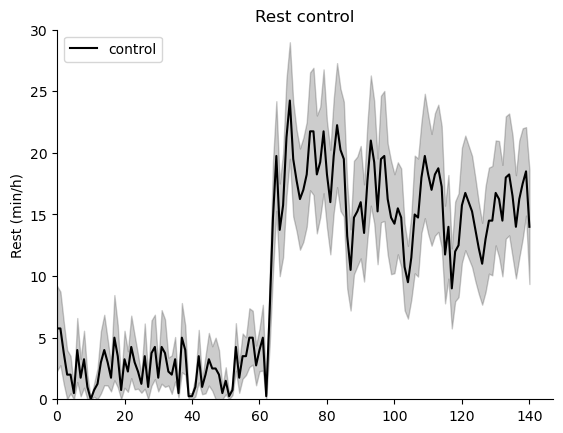

In [35]:
##Control
y = df_rest_control_hour.mean(axis=1)
x = np.linspace(0,len(y)-1,len(y))
print("len x",len(x))
print("len y",len(y))

# fit a linear curve and estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_ctrl = df_rest_control_hour.mean(axis=1)
y_err_ctrl = df_rest_control_hour.sem(axis=1)

fig, ax = plt.subplots()
ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')

ax.set_xlim(0,)
ax.set_ylim(0,lim_y)
ax.set_title("Rest "+str(ctrl_name))
ax.set_ylabel("Rest (min/h)")
plt.legend(loc="upper left")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\Rest_pooled_"+ctrl_name+"_only.pdf")

len x 145
len y 145


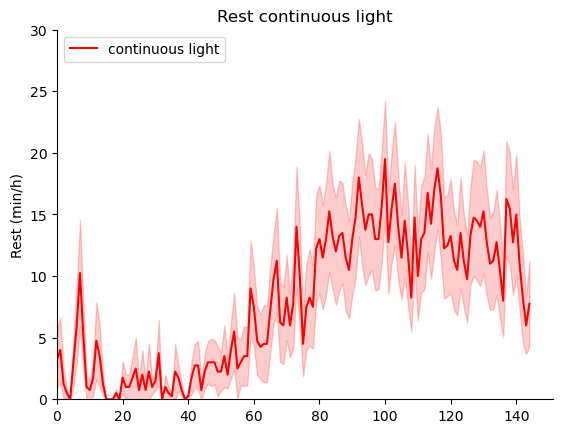

In [36]:
## Group 1
y = df_rest_continuouslight_hour.mean(axis=1)
x = np.linspace(0,len(y)-1,len(y))
print("len x",len(x))
print("len y",len(y))

# fit a linear curve and estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_cont = df_rest_continuouslight_hour.mean(axis=1)
y_err_cont = df_rest_continuouslight_hour.sem(axis=1)

fig, ax = plt.subplots()
ax.plot(x, y_est_cont, '-', color='red',label=group_1_name)
ax.fill_between(x, y_est_cont - y_err_cont, y_est_cont + y_err_cont, alpha=0.2, color='red')

ax.set_xlim(0,)
ax.set_ylim(0,lim_y)
ax.set_title("Rest "+str(group_1_name))
ax.set_ylabel("Rest (min/h)")
plt.legend(loc="upper left")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\Rest_pooled_"+str(group_1_name)+"_only.pdf")

len x 144
len y 144


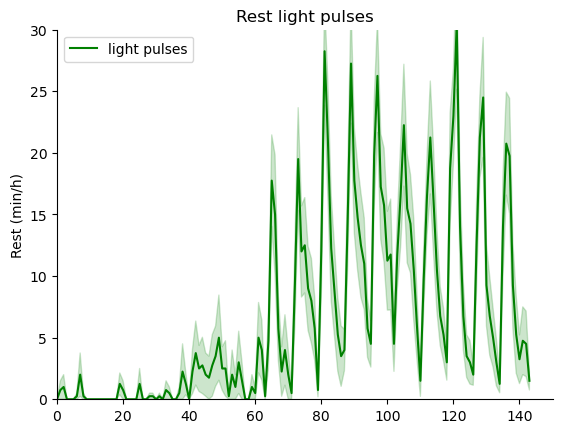

In [38]:
## Group 2
if group_nr>=3:
    y = df_rest_lp_hour.mean(axis=1)
    x = np.linspace(0,len(y)-1,len(y))
    print("len x",len(x))
    print("len y",len(y))
    
    # fit a linear curve and estimate its y-values and their error.
    a, b = np.polyfit(x, y, deg=1)
    y_est_lp = df_rest_lp_hour.mean(axis=1)
    y_err_lp = df_rest_lp_hour.sem(axis=1)
    
    fig, ax = plt.subplots()
    ax.plot(x, y_est_lp, '-', color='green',label=group_2_name)
    ax.fill_between(x, y_est_lp - y_err_lp, y_est_lp + y_err_lp, alpha=0.2, color='green')
    
    ax.set_xlim(0,)
    ax.set_ylim(0,lim_y)
    ax.set_title("Rest "+str(group_2_name))
    ax.set_ylabel("Rest (min/h)")
    plt.legend(loc="upper left")
        
    sns.despine(right=True, bottom=False)
    fig.savefig(path_graphics+r"\Rest_pooled_"+group_2_name+"_only.pdf")

**Wake Activity Single Graphs**

len x 141
len y 141


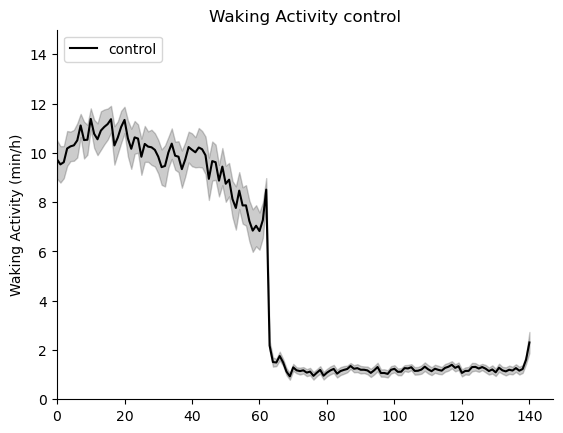

In [43]:
##Control
y = df_wakeAct_control_hour.mean(axis=1)
x = np.linspace(0,len(y)-1,len(y))
print("len x",len(x))
print("len y",len(y))

# fit a linear curve and estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_ctrl = df_wakeAct_control_hour.mean(axis=1)
y_err_ctrl = df_wakeAct_control_hour.sem(axis=1)

fig, ax = plt.subplots()
ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')

ax.set_xlim(0,)
ax.set_ylim(0,lim_y_wake)
ax.set_title("Waking Activity "+ctrl_name)
ax.set_ylabel("Waking Activity (min/h)")
plt.legend(loc="upper left")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\WakeAct_pooled_"+ctrl_name+"_only.pdf")

len x 145
len y 145


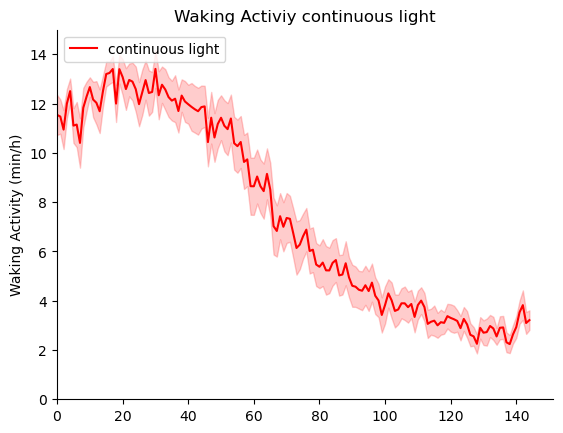

In [44]:
## Group 1
y = df_wakeAct_continuouslight_hour.mean(axis=1)
x = np.linspace(0,len(y)-1,len(y))
print("len x",len(x))
print("len y",len(y))

# fit a linear curve and estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_cont = df_wakeAct_continuouslight_hour.mean(axis=1)
y_err_cont = df_wakeAct_continuouslight_hour.sem(axis=1)

fig, ax = plt.subplots()
ax.plot(x, y_est_cont, '-', color='red',label=group_1_name)
ax.fill_between(x, y_est_cont - y_err_cont, y_est_cont + y_err_cont, alpha=0.2, color='red')

ax.set_xlim(0,)
ax.set_ylim(0,lim_y_wake)
ax.set_title("Waking Activiy "+group_1_name)
ax.set_ylabel("Waking Activity (min/h)")
plt.legend(loc="upper left")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\WakeAct_pooled_"+group_1_name+"_only.pdf")

len x 144
len y 144


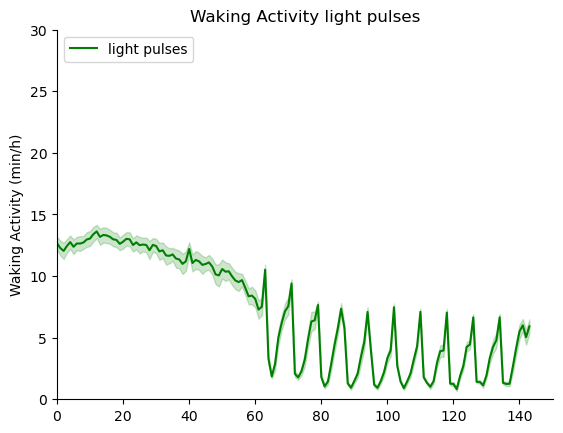

In [45]:
## Group2
if group_nr >= 3:
    y = df_wakeAct_lp_hour.mean(axis=1)
    x = np.linspace(0,len(y)-1,len(y))
    print("len x",len(x))
    print("len y",len(y))
    
    # fit a linear curve and estimate its y-values and their error.
    a, b = np.polyfit(x, y, deg=1)
    y_est_lp = df_wakeAct_lp_hour.mean(axis=1)
    y_err_lp = df_wakeAct_lp_hour.sem(axis=1)
    
    fig, ax = plt.subplots()
    ax.plot(x, y_est_lp, '-', color='green',label=group_2_name)
    ax.fill_between(x, y_est_lp - y_err_lp, y_est_lp + y_err_lp, alpha=0.2, color='green')
    
    ax.set_xlim(0,)
    ax.set_ylim(0,lim_y)
    ax.set_title("Waking Activity "+group_2_name)
    ax.set_ylabel("Waking Activity (min/h)")
    plt.legend(loc="upper left")
        
    sns.despine(right=True, bottom=False)
    fig.savefig(path_graphics+r"\WakeAct_pooled_"+group_2_name+"_only.pdf")

## Double Graphics
One condition shown together with the control.

## Group 2 & Control

In [46]:
# Cut control to same length as group2
if group_nr >=3:
    if len(df_rest_control_hour)>len(df_rest_lp_hour):
        stop = len(df_rest_control_hour)
        cut_helper = len(df_rest_lp_hour)#length of your stimulus
        df_rest_control_hour = df_rest_control_hour.drop(labels=range(cut_helper,stop), axis = 0)
    else:
        stop = len(df_rest_lp_hour)
        cut_helper = len(df_rest_control_hour)#length of your stimulus
        df_rest_lp_hour = df_rest_lp_hour.drop(labels=range(cut_helper,stop), axis = 0)

len x 141
len y 141


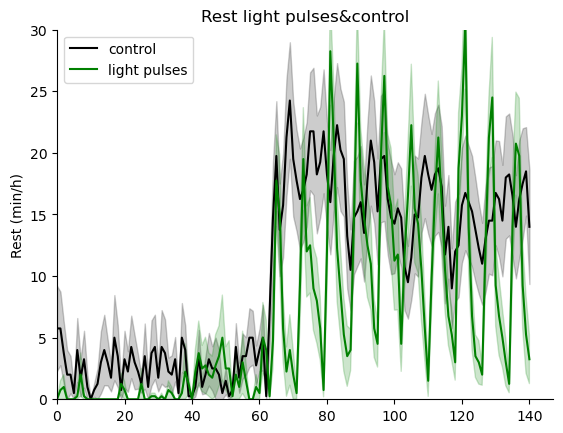

In [48]:
if group_nr >= 3:
    cut_helper_2 = len(df_rest_lp_hour)-1
    
    y = df_rest_lp_hour.mean(axis=1)
    x = np.arange(0, len(y), 1)
    print("len x",len(x))
    print("len y",len(y))
    
    
    
    # fit a linear curve an estimate its y-values and their error.
    a, b = np.polyfit(x, y, deg=1)
    y_est_ctrl = df_rest_control_hour.mean(axis=1)
    y_err_ctrl = df_rest_control_hour.sem(axis=1)
    
    y_est_lp=df_rest_lp_hour.mean(axis=1)
    y_err_lp = df_rest_lp_hour.sem(axis=1)
    
    
    fig, ax = plt.subplots()
    ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
    ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')
    
    ax.plot(x, y_est_lp, '-', color='green',label=group_2_name)
    ax.fill_between(x, y_est_lp - y_err_lp, y_est_lp + y_err_lp, alpha=0.2, color='green')
    
    #rectangle = plt.Rectangle((88,0),150, 60, fc='grey', alpha=0.2)
    #plt.gca().add_patch(rectangle)
    
    ax.set_xlim(0,)
    ax.set_ylim(0,lim_y)
    ax.set_title("Rest "+group_2_name+"&"+ctrl_name)
    
    ax.set_ylabel("Rest (min/h)")
    plt.legend(loc="upper left")
        
    sns.despine(right=True, bottom=False)
    fig.savefig(path_graphics+r"\Rest_pooled_"+group_2_name+"+"+ctrl_name+".pdf")

## Continuous & Control
To cut the control again, we first have to concatenate it anew and repeat the multiply step.

In [49]:
#concat controls
df_Act_control = pd.concat(act_ctrl_list, axis=1)
df_rest_control = pd.concat(rest_ctrl_list, axis=1)
df_wakeAct_control = pd.concat(wakeAct_ctrl_list, axis=1)

In [50]:
#hochrechnen auf 60 Minuten
df_rest_control_hour = df_rest_control.mul(tosixty)

In [51]:
# Cut control to same length as group 1
if len(df_rest_control_hour)>len(df_rest_continuouslight_hour):
    stop = len(df_rest_control_hour)
    cut_helper = len(df_rest_continuouslight_hour)#length of your stimulus
    df_rest_control_hour = df_rest_control_hour.drop(labels=range(cut_helper,stop), axis = 0)
else:
    stop = len(df_rest_continuouslight_hour)
    cut_helper = len(df_rest_control_hour)#length of your stimulus
    df_rest_continuouslight_hour = df_rest_continuouslight_hour.drop(labels=range(cut_helper,stop), axis = 0)

len x 141
len y 141


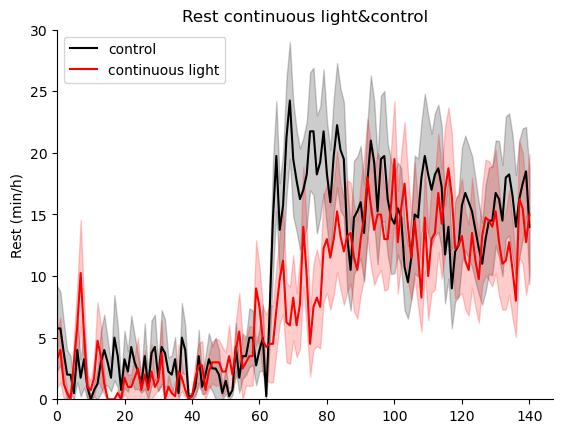

In [52]:
cut_helper_2 = len(df_rest_continuouslight_hour)-1

y = df_rest_continuouslight_hour.mean(axis=1)
x = np.linspace(0,cut_helper_2, cut_helper)
print("len x",len(x))
print("len y",len(y))

# fit a linear curve an estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_ctrl = df_rest_control_hour.mean(axis=1)
y_err_ctrl = df_rest_control_hour.sem(axis=1)

y_est_cont = df_rest_continuouslight_hour.mean(axis=1)
y_err_cont = df_rest_continuouslight_hour.sem(axis=1)


fig, ax = plt.subplots()
ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')

ax.plot(x, y_est_cont, '-', color='red',label=group_1_name)
ax.fill_between(x, y_est_cont - y_err_cont, y_est_cont + y_err_cont, alpha=0.2, color='red')

#rectangle = plt.Rectangle((88,0),150, 60, fc='grey', alpha=0.2)
#plt.gca().add_patch(rectangle)

ax.set_xlim(0,)
ax.set_ylim(0,lim_y)
ax.set_title("Rest "+group_1_name+"&"+ctrl_name)

ax.set_ylabel("Rest (min/h)")
plt.legend(loc="upper left")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\Rest_pooled_"+group_1_name+"+"+ctrl_name+".pdf")

## **Double Graphics - Waking Activity**

## Control & Tapping

In [54]:
# Cut control to same length as group_2
if group_nr >=3:
    if len(df_wakeAct_control_hour)>len(df_wakeAct_lp_hour):
        stop = len(df_wakeAct_control_hour)
        cut_helper = len(df_wakeAct_lp_hour)#length of your stimulus
        df_wakeAct_control_hour = df_wakeAct_control_hour.drop(labels=range(cut_helper,stop), axis = 0)
    else:
        stop = len(df_wakeAct_lp_hour)
        cut_helper = len(df_wakeAct_control_hour)#length of your stimulus
        df_wakeAct_lp_hour = df_wakeAct_lp_hour.drop(labels=range(cut_helper,stop), axis = 0)

len x 141
len y 141


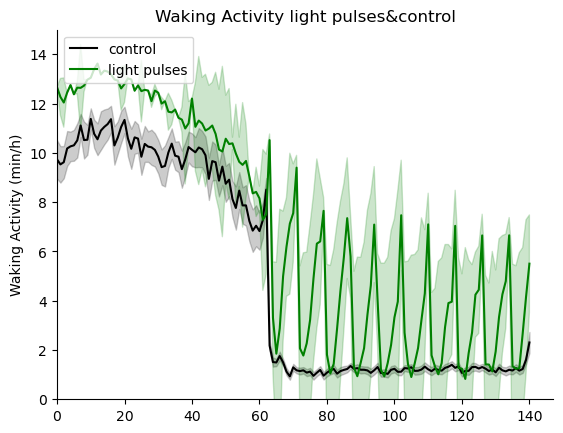

In [55]:
if group_nr >= 3:
    cut_helper_2 = len(df_wakeAct_lp_hour)-1
    
    y = df_wakeAct_lp_hour.mean(axis=1)
    x = np.arange(0, len(y), 1)
    print("len x",len(x))
    print("len y",len(y))
    
    
    
    # fit a linear curve an estimate its y-values and their error.
    a, b = np.polyfit(x, y, deg=1)
    y_est_ctrl = df_wakeAct_control_hour.mean(axis=1)
    y_err_ctrl = df_wakeAct_control_hour.sem(axis=1)
    
    y_est_lp=df_wakeAct_lp_hour.mean(axis=1)
    y_err_lpp = df_wakeAct_lp_hour.sem(axis=1)
    
    
    fig, ax = plt.subplots()
    ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
    ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')
    
    ax.plot(x, y_est_lp, '-', color='green',label=group_2_name)
    ax.fill_between(x, y_est_lp - y_err_lp, y_est_lp + y_err_lp, alpha=0.2, color='green')
    
    #rectangle = plt.Rectangle((88,0),150, 60, fc='grey', alpha=0.2)
    #plt.gca().add_patch(rectangle)
    
    ax.set_xlim(0,)
    ax.set_ylim(0,lim_y_wake)
    ax.set_title("Waking Activity "+group_2_name+"&"+ctrl_name)
    
    ax.set_ylabel("Waking Activity (min/h)")
    plt.legend(loc="upper left")
        
    sns.despine(right=True, bottom=False)
    fig.savefig(path_graphics+r"\WakeAct_pooled_"+group_2_name+"+"+ctrl_name+".pdf")

## Continuous Light & Control

In [56]:
#concat controls
df_Act_control = pd.concat(act_ctrl_list, axis=1)
df_rest_control = pd.concat(rest_ctrl_list, axis=1)
df_wakeAct_control = pd.concat(wakeAct_ctrl_list, axis=1)

In [57]:
#hochrechnen auf 60 Minuten
df_rest_control_hour = df_rest_control.mul(1)

In [58]:
# Cut control to same length as continuous light
if len(df_wakeAct_control_hour)>len(df_wakeAct_continuouslight_hour):
    stop = len(df_wakeAct_control_hour)
    cut_helper = len(df_wakeAct_continuouslight_hour)#length of your stimulus
    df_wakeAct_control_hour = df_wakeAct_control_hour.drop(labels=range(cut_helper,stop), axis = 0)
else:
    stop = len(df_wakeAct_continuouslight_hour)
    cut_helper = len(df_wakeAct_control_hour)#length of your stimulus
    df_wakeAct_continuouslight_hour = df_wakeAct_continuouslight_hour.drop(labels=range(cut_helper,stop), axis = 0)

len x 141
len y 141


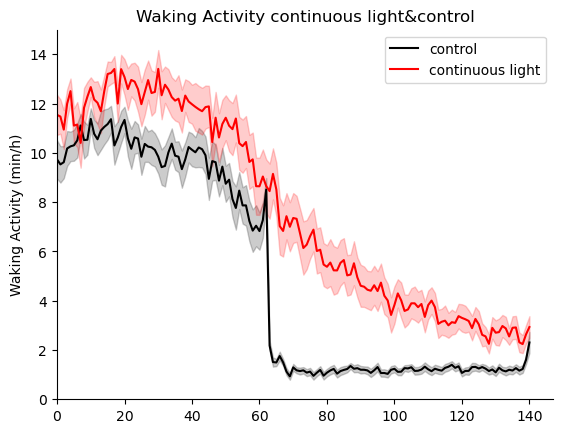

In [59]:
cut_helper_2 = len(df_wakeAct_continuouslight_hour)-1

y = df_wakeAct_continuouslight_hour.mean(axis=1)
x = np.linspace(0,cut_helper_2, cut_helper)
print("len x",len(x))
print("len y",len(y))

# fit a linear curve an estimate its y-values and their error.
a, b = np.polyfit(x, y, deg=1)
y_est_ctrl = df_wakeAct_control_hour.mean(axis=1)
y_err_ctrl = df_wakeAct_control_hour.sem(axis=1)

y_est_cont = df_wakeAct_continuouslight_hour.mean(axis=1)
y_err_cont = df_wakeAct_continuouslight_hour.sem(axis=1)


fig, ax = plt.subplots()
ax.plot(x, y_est_ctrl, '-', color='black',label=ctrl_name)
ax.fill_between(x, y_est_ctrl - y_err_ctrl, y_est_ctrl + y_err_ctrl, alpha=0.2, color='black')

ax.plot(x, y_est_cont, '-', color='red',label=group_1_name)
ax.fill_between(x, y_est_cont - y_err_cont, y_est_cont + y_err_cont, alpha=0.2, color='red')

#rectangle = plt.Rectangle((88,0),150, 60, fc='grey', alpha=0.2)
#plt.gca().add_patch(rectangle)

ax.set_xlim(0,)
ax.set_ylim(0,lim_y_wake)
ax.set_title("Waking Activity "+group_1_name+"&"+ctrl_name)

ax.set_ylabel("Waking Activity (min/h)")
plt.legend(loc="best")
    
sns.despine(right=True, bottom=False)
fig.savefig(path_graphics+r"\WakeAct_pooled_"+group_1_name+"+"+ctrl_name+".pdf")

## Bar plots - Rest
First, load the data & convert it into a dataframe.
You may have to add stuff here if you have more groups than 3.

In [63]:
# --- Build dicts (only the specific CSV files) ---

#ctrl
try:
    ctrl_dict = {
        "day0":      os.path.join(ctrl_filepath, "output_binned_rest_day0.csv"),
        "night1":     os.path.join(ctrl_filepath, "output_binned_rest_night1.csv"),
        "day1":  os.path.join(ctrl_filepath, "output_binned_rest_day1.csv"),
        "testphase":  os.path.join(ctrl_filepath, "output_binned_rest_testphase.csv"),
    }
except:
    pass

#group1
try:
    cont_dict = {
        "day0":      os.path.join(grp1_filepath, "output_binned_rest_day0.csv"),
        "night1":     os.path.join(grp1_filepath, "output_binned_rest_night1.csv"),
        "day1":  os.path.join(grp1_filepath, "output_binned_rest_day1.csv"),
        "testphase":  os.path.join(grp1_filepath, "output_binned_rest_testphase.csv"),
    }
except:
    pass

#group2
try:
    if group_nr >= 3:
        grp2_dict = {
        "day0":      os.path.join(grp2_filepath, "output_binned_rest_day0.csv"),
        "night1":     os.path.join(grp2_filepath, "output_binned_rest_night1.csv"),
        "day1":  os.path.join(grp2_filepath, "output_binned_rest_day1.csv"),
        "testphase":  os.path.join(grp2_filepath, "output_binned_rest_testphase.csv"),
        }
except:
    pass

# --- Read CSVs ---

#ctrl
try:
    df_day0_control    = pd.read_csv(ctrl_dict["day0"],     header=None)
    df_night1_control   = pd.read_csv(ctrl_dict["night1"],    header=None)
    df_day1_control= pd.read_csv(ctrl_dict["day1"], header=None)
    df_testphase_control= pd.read_csv(ctrl_dict["testphase"], header=None)
except:
    pass

#group1
try:
    df_day0_continuouslight    = pd.read_csv(cont_dict["day0"],     header=None)
    df_night1_continuouslight  = pd.read_csv(cont_dict["night1"],    header=None)
    df_day1_continuouslight = pd.read_csv(cont_dict["day1"], header=None)
    df_testphase_continuouslight = pd.read_csv(cont_dict["testphase"], header=None)
except:
    pass

#group2
try:
    if group_nr >= 3:
        df_day0_lp    = pd.read_csv(grp2_dict["day0"],     header=None)
        df_night1_lp = pd.read_csv(grp2_dict["night1"],    header=None)
        df_day1_lp = pd.read_csv(grp2_dict["day1"], header=None)
        df_testphase_lp = pd.read_csv(grp2_dict["testphase"], header=None)
except:
    pass

## Multiply time to 60 minutes
Changes the unit for rest from minute/binned minutes to minute/hour. This calculation uses the binned time from the beginning, so there may be errors in your data if you forgot to change the number accordingly!

In [66]:
tosixty = 6/binned

#control
df_day0_control = df_day0_control.mul(tosixty)
df_night1_control = df_night1_control.mul(tosixty)
try:
    df_day1_control = df_day1_control.mul(tosixty)
except:
    pass
try:
    df_testphase_control = df_testphase_control.mul(tosixty)
except:
    pass

#continuous light
df_day0_continuouslight = df_day0_continuouslight.mul(tosixty)
df_night1_continuouslight = df_night1_continuouslight.mul(tosixty)
try:
    df_day1_continuouslight = df_day1_continuouslight.mul(tosixty)
except:
    pass
try:
    df_testphase_continuouslight = df_testphase_continuouslight.mul(tosixty)
except:
    pass

if group_nr >=3:
    #group3
    df_day0_lp = df_day0_lp.mul(tosixty)
    df_night1_lp = df_night1_lp.mul(tosixty)
    try:
        df_day1_lp = df_day1_lp.mul(tosixty)
    except:
        pass
    try:
        df_testphase_lp = df_testphase_lp.mul(tosixty)
    except:
        pass

## Mean per fish
Get the column averages (which are the means per fish).
Skip the NaNs.

In [67]:
#control
mean_df_day0_control = df_day0_control.mean(axis=0,skipna=True)
mean_df_night1_control = df_night1_control.mean(axis=0,skipna=True)

try:
    mean_df_day1_control = df_day1_control.mean(axis=0,skipna=True)
except:
    pass
try:
    mean_df_testphase_control = df_testphase_control.mean(axis=0,skipna=True)
except:
    pass

In [68]:
#group1
mean_df_day0_continuouslight = df_day0_continuouslight.mean(axis=0,skipna=True)
mean_df_night1_continuouslight = df_night1_continuouslight.mean(axis=0,skipna=True)
try:
    mean_df_day1_continuouslight = df_day1_continuouslight.mean(axis=0,skipna=True)
except:
    pass
try:
    mean_df_testphase_continuouslight = df_testphase_continuouslight.mean(axis=0,skipna=True)
except:
    pass

In [69]:
#group2
if group_nr >=3:
    mean_df_day0_lp = df_day0_lp.mean(axis=0,skipna=True)
    mean_df_night1_lp = df_night1_lp.mean(axis=0,skipna=True)
    try:
        mean_df_day1_lp = df_day1_lp.mean(axis=0,skipna=True)
    except:
        pass
    try:
        mean_ddf_testphase_lp = df_testphase_lp.mean(axis=0,skipna=True)
    except:
        pass

## Bar plot graphics
All conditions together. <3

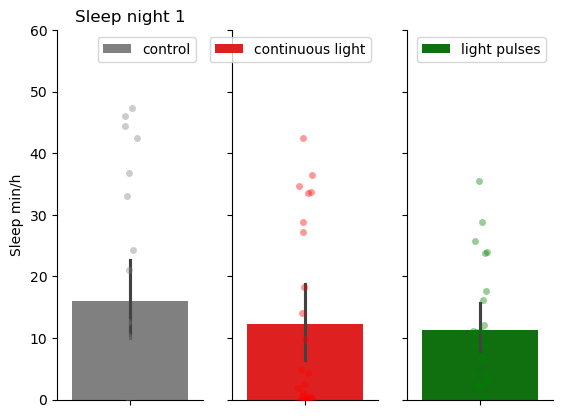

In [71]:
# Sleep Night 1
if group_nr == 2:
    fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
elif group_nr ==3:
    fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
ax = sns.barplot(ax=ax1,y=mean_df_night1_control, color = "grey", orient="v", label=ctrl_name)
ax = sns.stripplot(ax=ax1,data=mean_df_night1_control, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)

ax = sns.barplot(ax=ax2, y=mean_df_night1_continuouslight, color = "red", orient="v", label=group_1_name)
ax = sns.stripplot(ax=ax2,data=mean_df_night1_continuouslight, dodge=True, color="red", alpha = 0.4,jitter = 0.05)

if group_nr >=3:
    ax = sns.barplot(ax=ax3, y=mean_df_night1_lp, color = "green", orient="v", label=group_2_name)
    ax = sns.stripplot(ax=ax3,data=mean_df_night1_lp, dodge=True, color="green", alpha = 0.4,jitter = 0.05)

ax1.set_title("Sleep night 1")
ax1.set_ylabel("Sleep min/h")
ax1.set_ylim(0,lim_y_bp_sleep)
sns.despine(right=True, bottom=False)
ax.legend()
fig.savefig(path_graphics+r"\Bar_plot_sleep_night1.pdf")

In [74]:
try: 
    with open(output_file, "a") as f:
        f.write("\n\n**Sleep night1**"+"\n")
        
    if group_nr == 2:
        list_dfs = [mean_df_night1_control, mean_df_night1_continuouslight]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_night1_control, mean_df_night1_continuouslight, mean_df_night1_lp]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var =statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!


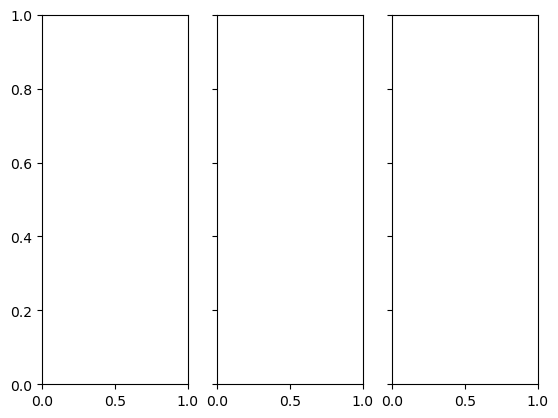

In [75]:
# Sleep Day 1
try:
    if group_nr == 2:
        fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
    elif group_nr ==3:
        fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
    ax = sns.barplot(ax=ax1,y=mean_df_day1_control, color = "grey", orient="v", label=ctrl_name)
    ax = sns.stripplot(ax=ax1,data=mean_df_day1_control, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)
    
    ax = sns.barplot(ax=ax2, y=mean_df_day1_continuouslight, color = "red", orient="v", label=group_1_name)
    ax = sns.stripplot(ax=ax2,data=mean_df_day1_continuouslight, dodge=True, color="red", alpha = 0.4,jitter = 0.05)
    
    if group_nr >=3:
        ax = sns.barplot(ax=ax3, y=mean_df_day1_lp, color = "green", orient="v", label=group_2_name)
        ax = sns.stripplot(ax=ax3,data=mean_df_day1_lp, dodge=True, color="green", alpha = 0.4,jitter = 0.05)
    
    ax1.set_title("Sleep day 1")
    ax1.set_ylabel("Sleep min/h")
    ax1.set_ylim(0,lim_y_bp_sleep)
    sns.despine(right=True, bottom=False)
    ax.legend()
    fig.savefig(path_graphics+r"\Bar_plot_sleep_day1.pdf")
except:
    pass

In [76]:
try: 
    with open(output_file, "a") as f:
        f.write("\n\n**Sleep day1**"+"\n")
        
    if group_nr == 2:
        list_dfs = [mean_df_day1_control, mean_df_day1_continuouslight]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_day1_control, mean_df_day1_continuouslight, mean_df_day1_lp]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var =statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!


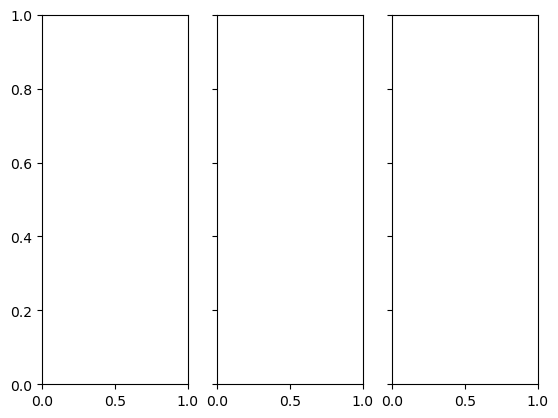

In [77]:
# Sleep Rebound Phase
try:
    if group_nr == 2:
        fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
    elif group_nr ==3:
        fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
    ax = sns.barplot(ax=ax1,y=mean_df_testphase_control, color = "grey", orient="v", label="control")
    ax = sns.stripplot(ax=ax1,data=mean_df_testphase_control, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)
    
    ax = sns.barplot(ax=ax2, y=mean_df_testphase_continuouslight, color = "red", orient="v", label=group_1_name)
    ax = sns.stripplot(ax=ax2,data=mean_df_testphase_continuouslight, dodge=True, color="red", alpha = 0.4,jitter = 0.05)

    if group_nr >=3:
        ax = sns.barplot(ax=ax3, y=mean_ddf_testphase_lp, color = "green", orient="v", label=group_2_name)
        ax = sns.stripplot(ax=ax3,data=mean_ddf_testphase_lp, dodge=True, color="green", alpha = 0.4,jitter = 0.05)
    
    ax1.set_title("Sleep during rebound phase")
    ax1.set_ylabel("Sleep min/h")
    ax1.set_ylim(0,lim_y_bp_sleep)
    sns.despine(right=True, bottom=False)
    ax.legend()
    fig.savefig(path_graphics+r"\Bar_plot_sleep_rebound.pdf")
except:
    pass

In [42]:
try: 
    with open(output_file, "a") as f:
        f.write("\n\n**Sleep rebound phase**"+"\n")
        
    if group_nr == 2:
        list_dfs = [mean_df_testphase_control, mean_df_testphase_continuouslight]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_testphase_control, mean_df_testphase_continuouslight, mean_ddf_testphase_lp]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var =statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!


## Bar Graphs - Waking Activity

In [94]:
# --- Build dicts (only the specific CSV files) ---

#ctrl
try:
    ctrl_dict = {
        "day0":      os.path.join(ctrl_filepath, "output_binned_wakeAct_day0.csv"),
        "night1":     os.path.join(ctrl_filepath, "output_binned_wakeAct_night1.csv"),
        "day1":  os.path.join(ctrl_filepath, "output_binned_wakeAct_day1.csv"),
        "testphase":  os.path.join(ctrl_filepath, "output_binned_wakeAct_testphase.csv"),
    }
except:
    pass

#group1
try:
    cont_dict = {
        "day0":      os.path.join(grp1_filepath, "output_binned_wakeAct_day0.csv"),
        "night1":     os.path.join(grp1_filepath, "output_binned_wakeAct_night1.csv"),
        "day1":  os.path.join(grp1_filepath, "output_binned_wakeAct_day1.csv"),
        "testphase":  os.path.join(grp1_filepath, "output_binned_wakeAct_testphase.csv"),
    }
except:
    pass

#group2
try:
    if group_nr >= 3:
        grp2_dict = {
        "day0":      os.path.join(grp2_filepath, "output_binned_wakeAct_day0.csv"),
        "night1":     os.path.join(grp2_filepath, "output_binned_wakeAct_night1.csv"),
        "day1":  os.path.join(grp2_filepath, "output_binned_wakeAct_day1.csv"),
        "testphase":  os.path.join(grp2_filepath, "output_binned_wakeAct_testphase.csv"),
        }
except:
    pass

# --- Read CSVs ---

#ctrl
try:
    df_wakeAct_control_day0    = pd.read_csv(ctrl_dict["day0"],     header=None)
    df_wakeAct_control_night1   = pd.read_csv(ctrl_dict["night1"],    header=None)
    df_wakeAct_control_day1= pd.read_csv(ctrl_dict["day1"], header=None)
    df_wakeAct_control_testphase= pd.read_csv(ctrl_dict["testphase"], header=None)
except:
    pass

#group1
try:
    df_wakeAct_continuouslight_day0    = pd.read_csv(cont_dict["day0"],     header=None)
    df_wakeAct_continuouslight_night1  = pd.read_csv(cont_dict["night1"],    header=None)
    df_wakeAct_continuouslight_day1_= pd.read_csv(cont_dict["day1"], header=None)
    df_wakeAct_continuouslight_testphase = pd.read_csv(cont_dict["testphase"], header=None)
except:
    pass

#group2
try:
    if group_nr >= 3:
        df_wakeAct_lp_day0   = pd.read_csv(grp2_dict["day0"],     header=None)
        df_wakeAct_lp_night1 = pd.read_csv(grp2_dict["night1"],    header=None)
        df_wakeAct_lp_day1 = pd.read_csv(grp2_dict["day1"], header=None)
        df_wakeAct_lp_testphase = pd.read_csv(grp2_dict["testphase"], header=None)
except:
    pass

## Mean per Fish

In [95]:
#control
mean_df_wakeAct_control_night1 = df_wakeAct_control_night1.mean(axis=0,skipna=True)
try:
    mean_df_wakeAct_control_day1 = df_wakeAct_control_day1.mean(axis=0,skipna=True)
except:
    pass
try:
    mean_df_wakeAct_control_rebound = df_wakeAct_control_testphase.mean(axis=0,skipna=True)
except:
    pass

In [96]:
#continuous light
mean_df_wakeAct_continuouslight_night1 = df_wakeAct_continuouslight_night1.mean(axis=0,skipna=True)
try:
    mean_df_wakeAct_continuouslight_day1 = df_wakeAct_continuouslight_day1.mean(axis=0,skipna=True)
except:
    pass
try:
    mean_df_wakeAct_continuouslight_rebound = df_wakeAct_continuouslight_testphase.mean(axis=0,skipna=True)
except:
    pass

In [99]:
#tapping
try:
    mean_mean_df_wakeAct_lp_night1 = df_wakeAct_lp_night1.mean(axis=0,skipna=True)
    try:
        mean_df_wakeAct_lp_day1 = df_wakeAct_lp_day1.mean(axis=0,skipna=True)
    except:
        pass
    try:
        mean_df_wakeAct_lp_rebound = df_wakeAct_lp_testphase.mean(axis=0,skipna=True)
    except:
        pass
except:
    pass

## Bar plots

NameError: name 'mean_df_wakeAct_lp_night1' is not defined

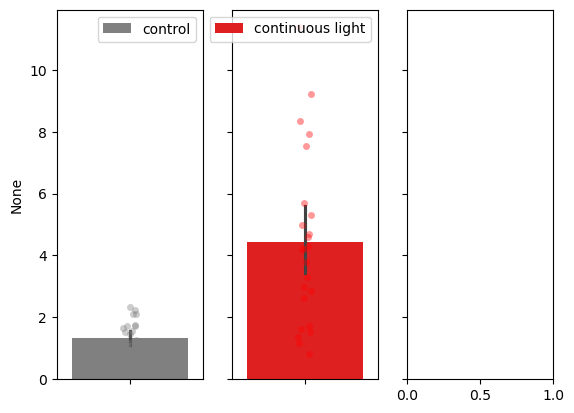

In [100]:
# Waking Activity Night 1

if group_nr == 2:
    fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
elif group_nr ==3:
    fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
ax = sns.barplot(ax=ax1,y=mean_df_wakeAct_control_night1, color = "grey", orient="v", label=ctrl_name)
ax = sns.stripplot(ax=ax1,data=mean_df_wakeAct_control_night1, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)

ax = sns.barplot(ax=ax2, y=mean_df_wakeAct_continuouslight_night1, color = "red", orient="v", label=group_1_name)
ax = sns.stripplot(ax=ax2,data=mean_df_wakeAct_continuouslight_night1, dodge=True, color="red", alpha = 0.4,jitter = 0.05)
if group_nr >=3:
    ax = sns.barplot(ax=ax3, y=mean_df_wakeAct_lp_night1, color = "green", orient="v", label=group_2_name)
    ax = sns.stripplot(ax=ax3,data=mean_df_wakeAct_lp_night1, dodge=True, color="green", alpha = 0.4,jitter = 0.05)

ax1.set_title("Waking Activity night 1")
ax1.set_ylabel("Waking Activity min/h")
ax1.set_ylim(0,lim_y_bp_wake)
sns.despine(right=True, bottom=False)
ax.legend()
fig.savefig(path_graphics+r"\Bar_plot_wakeAct_night1.pdf")

In [85]:
try: 
    with open(output_file, "a") as f:
        f.write("\n\n**Waking Activity night 1**"+"\n")
        
    if group_nr == 2:
        list_dfs = [mean_df_wakeAct_control_night1, mean_df_wakeAct_continuouslight_night1]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_wakeAct_control_night1, mean_df_wakeAct_continuouslight_night1, mean_df_wakeAct_lp_night1]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var =statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!


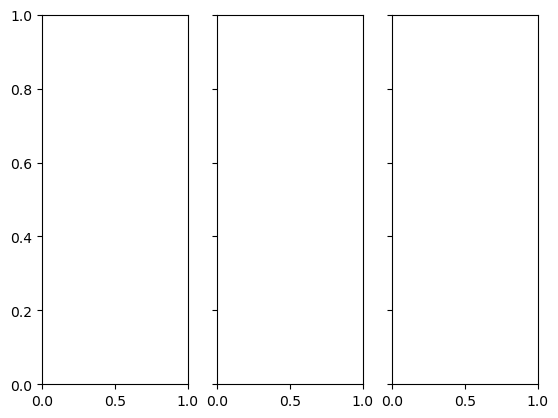

In [86]:
# Waking Activity Day 1
try:
    if group_nr == 2:
        fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
    elif group_nr ==3:
        fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
    ax = sns.barplot(ax=ax1,y=mean_df_wakeAct_control_day1, color = "grey", orient="v", label=ctrl_name)
    ax = sns.stripplot(ax=ax1,mean_data=df_wakeAct_control_day1, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)
    
    ax = sns.barplot(ax=ax2, y=mean_df_wakeAct_continuouslight_day1, color = "red", orient="v", label=group_1_name)
    ax = sns.stripplot(ax=ax2,data=mean_df_wakeAct_continuouslight_day1, dodge=True, color="red", alpha = 0.4,jitter = 0.05)

    if group_nr >=3:
        ax = sns.barplot(ax=ax3, y=mean_df_wakeAct_lp_day1, color = "green", orient="v", label=group_2_name)
        ax = sns.stripplot(ax=ax3,data=mean_df_wakeAct_lp_day1, dodge=True, color="green", alpha = 0.4,jitter = 0.05)
    
    ax1.set_title("Waking Activity day 1")
    ax1.set_ylabel("Waking Activity min/h")
    ax1.set_ylim(0,lim_y_bp_wake)
    sns.despine(right=True, bottom=False)
    ax.legend()
    fig.savefig(path_graphics+r"\Bar_plot_wakeAct_day1.pdf")
except:
    pass

In [87]:
try: 
    with open(output_file, "a") as f:
        f.write("\n\n**Waking Activity day 1**"+"\n")
        
    if group_nr == 2:
        list_dfs = [mean_df_wakeAct_control_day1, mean_df_wakeAct_continuouslight_day1]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_wakeAct_control_day1, mean_df_wakeAct_continuouslight_day1, mean_df_wakeAct_lp_day1]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var =statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!


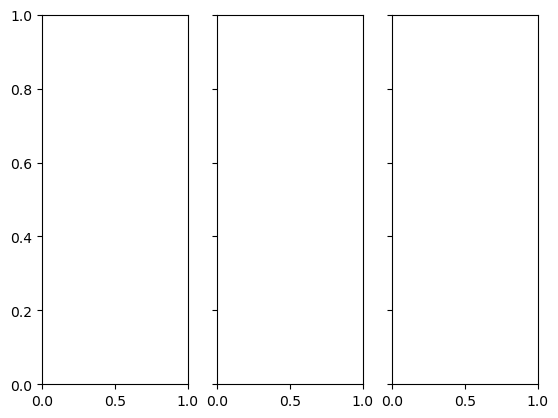

In [89]:
# Sleep Rebound Phase
try:
    if group_nr == 2:
        fig, (ax1, ax2) = plt.subplots(1, group_nr, sharey=True)
    elif group_nr ==3:
        fig, (ax1, ax2, ax3) = plt.subplots(1, group_nr, sharey=True)
    ax = sns.barplot(ax=ax1,y=mean_df_wakeAct_control_testphase, color = "grey", orient="v", label=ctrl_name)
    ax = sns.stripplot(ax=ax1,data=mean_df_wakeAct_control_testphase, dodge=True, color="grey", alpha = 0.4,jitter = 0.05)
    
    ax = sns.barplot(ax=ax2, y=mean_df_wakeAct_continuouslight_testphase, color = "red", orient="v", label=group_1_name)
    ax = sns.stripplot(ax=ax2,data=mean_df_wakeAct_continuouslight_testphase, dodge=True, color="red", alpha = 0.4,jitter = 0.05)
    
    if group_nr >=3:
        ax = sns.barplot(ax=ax3, y=mean_df_wakeAct_lp_testphase, color = "green", orient="v", label=group_2_name)
        ax = sns.stripplot(ax=ax3,data=mean_df_wakeAct_lp_testphase, dodge=True, color="green", alpha = 0.4,jitter = 0.05)
        
    ax1.set_title("Waking Activity during rebound phase")
    ax1.set_ylabel("Waking Activity min/h")
    ax1.set_ylim(0,lim_y_bp_wake)
    sns.despine(right=True, bottom=False)
    ax.legend()
    fig.savefig(path_graphics+r"\Bar_plot_wakeAct_rebound.pdf")
except:
    pass

In [90]:
try:
    with open(output_file, "a") as f:
        f.write("\n\n**Waking Activity rebound phase**"+"\n")
         
    if group_nr == 2:
        list_dfs = [mean_df_wakeAct_control_testphase, mean_df_wakeAct_continuouslight_testphase]
        list_names = [ctrl_name, group_1_name]
        statistics(kruskal_var, output_file, list_dfs, list_names)
    elif group_nr == 3:
        list_dfs = [mean_df_wakeAct_control_testphase, mean_df_wakeAct_continuouslight_testphase, mean_df_wakeAct_lp_testphase]
        list_names = [ctrl_name, group_1_name, group_2_name]
        kruskal_var = statistics(kruskal_var, output_file, list_dfs, list_names) 
except:
    print("There seems to be an error or no data!")

There seems to be an error or no data!
